# PHASE 1: TIỀN XỬ LÝ DỮ LIỆU MQTT
## Hệ thống phát hiện tấn công DDoS trong mạng IoT

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pickle
import warnings
warnings.filterwarnings('ignore')

os.makedirs('Phase1_Data', exist_ok=True)
os.makedirs('Phase1_Models', exist_ok=True)
os.makedirs('Images', exist_ok=True)

print("=" * 60)
print("PHASE 1: TIỀN XỬ LÝ DỮ LIỆU MQTT")
print("=" * 60)

PHASE 1: TIỀN XỬ LÝ DỮ LIỆU MQTT


## BƯỚC 1: LOAD DỮ LIỆU

In [2]:
print("\nBƯỚC 1: LOAD DỮ LIỆU")
print("-" * 40)

train_df = pd.read_csv('MQTT/train70_reduced.csv')
test_df = pd.read_csv('MQTT/test30_reduced.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")


BƯỚC 1: LOAD DỮ LIỆU
----------------------------------------
Train shape: (231646, 34)
Test shape: (99290, 34)


## BƯỚC 2: PHÂN TÍCH DỮ LIỆU

In [3]:
print("\nBƯỚC 2: PHÂN TÍCH DỮ LIỆU")
print("-" * 40)

print("\nLabel distribution in train:")
train_counts = train_df['target'].value_counts()
print(train_counts)

print("\nLabel distribution in test:")
test_counts = test_df['target'].value_counts()
print(test_counts)


BƯỚC 2: PHÂN TÍCH DỮ LIỆU
----------------------------------------

Label distribution in train:
target
legitimate    115824
dos            91156
bruteforce     10150
malformed       7646
slowite         6441
flood            429
Name: count, dtype: int64

Label distribution in test:
target
legitimate    49639
dos           39077
bruteforce     4351
malformed      3278
slowite        2761
flood           184
Name: count, dtype: int64


## VISUALIZATION: LABEL DISTRIBUTION

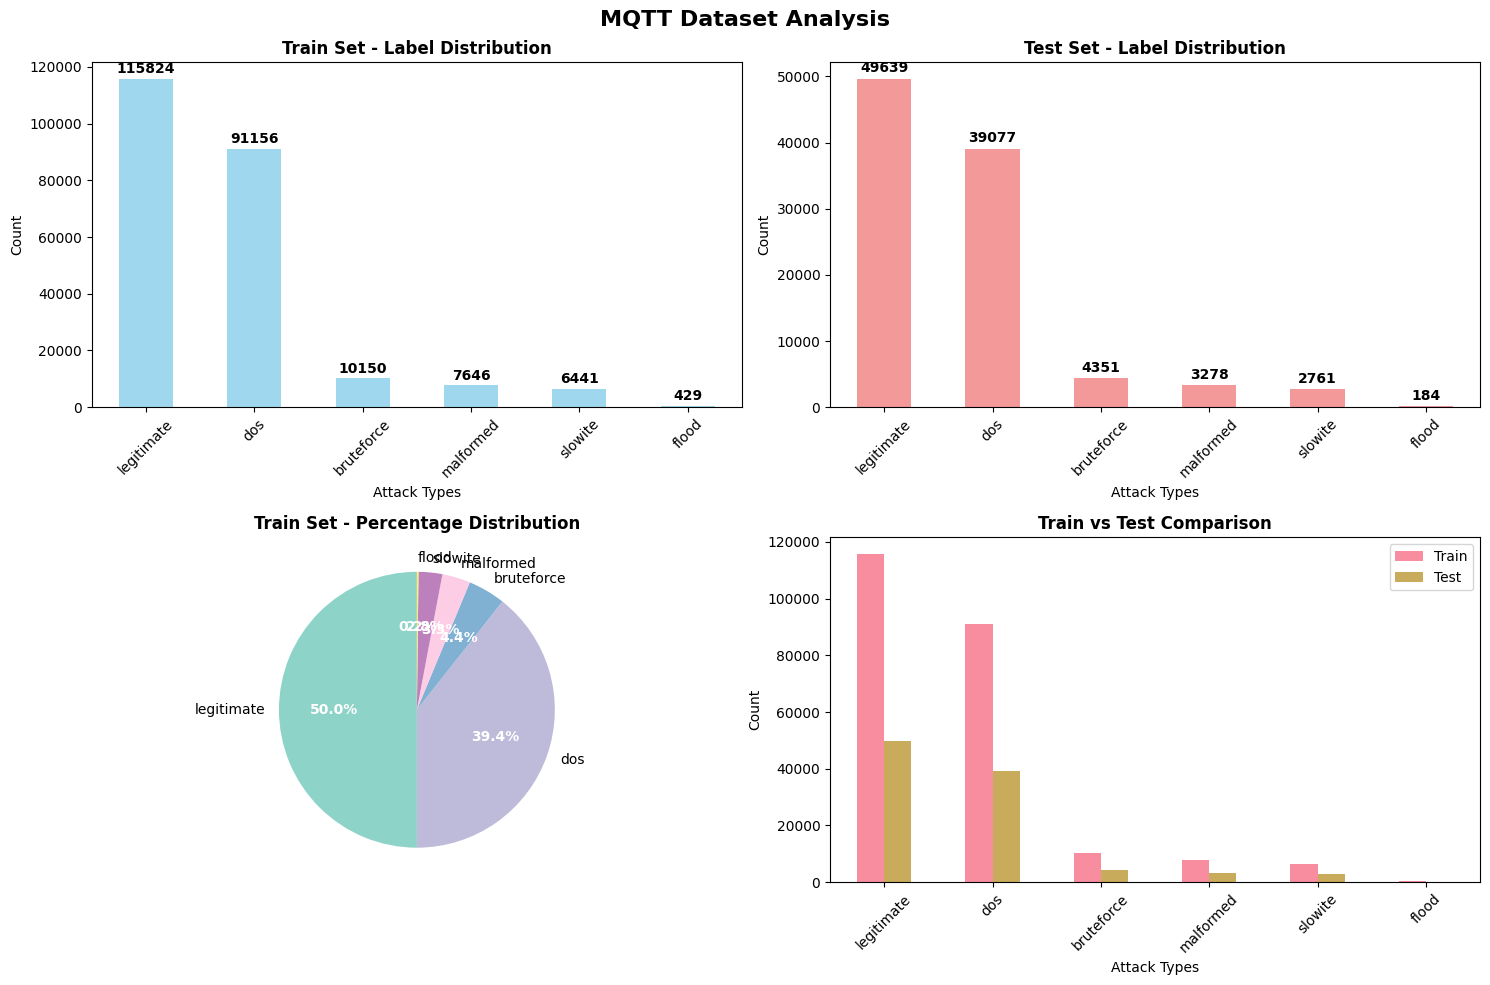


Dataset Statistics:
Total samples - Train: 231,646, Test: 99,290
Class imbalance ratio (max/min): 269.99
Most common class: legitimate (50.0%)
Least common class: flood (0.2%)


In [4]:
# Set style
plt.style.use('default')
sns.set_palette("husl")

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('MQTT Dataset Analysis', fontsize=16, fontweight='bold')

# 1. Train distribution (bar plot)
ax1 = axes[0, 0]
train_counts.plot(kind='bar', ax=ax1, color='skyblue', alpha=0.8)
ax1.set_title('Train Set - Label Distribution', fontweight='bold')
ax1.set_xlabel('Attack Types')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(train_counts.values):
    ax1.text(i, v + 1000, str(v), ha='center', va='bottom', fontweight='bold')

# 2. Test distribution (bar plot)
ax2 = axes[0, 1]
test_counts.plot(kind='bar', ax=ax2, color='lightcoral', alpha=0.8)
ax2.set_title('Test Set - Label Distribution', fontweight='bold')
ax2.set_xlabel('Attack Types')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)
for i, v in enumerate(test_counts.values):
    ax2.text(i, v + 500, str(v), ha='center', va='bottom', fontweight='bold')

# 3. Train distribution (pie chart)
ax3 = axes[1, 0]
colors = plt.cm.Set3(np.linspace(0, 1, len(train_counts)))
wedges, texts, autotexts = ax3.pie(train_counts.values, labels=train_counts.index, 
                                   autopct='%1.1f%%', colors=colors, startangle=90)
ax3.set_title('Train Set - Percentage Distribution', fontweight='bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# 4. Comparison chart
ax4 = axes[1, 1]
comparison_df = pd.DataFrame({
    'Train': train_counts,
    'Test': test_counts
}).fillna(0)
comparison_df.plot(kind='bar', ax=ax4, alpha=0.8)
ax4.set_title('Train vs Test Comparison', fontweight='bold')
ax4.set_xlabel('Attack Types')
ax4.set_ylabel('Count')
ax4.tick_params(axis='x', rotation=45)
ax4.legend()

plt.tight_layout()
plt.savefig('Images/Phase1_MQTT_label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics
print(f"\nDataset Statistics:")
print(f"Total samples - Train: {len(train_df):,}, Test: {len(test_df):,}")
print(f"Class imbalance ratio (max/min): {train_counts.max()/train_counts.min():.2f}")
print(f"Most common class: {train_counts.index[0]} ({train_counts.iloc[0]/len(train_df)*100:.1f}%)")
print(f"Least common class: {train_counts.index[-1]} ({train_counts.iloc[-1]/len(train_df)*100:.1f}%)")

## BƯỚC 3: XỬ LÝ FEATURES

In [5]:
print("\nBƯỚC 3: XỬ LÝ FEATURES")
print("-" * 40)

X_train = train_df.drop('target', axis=1)
y_train = train_df['target']
X_test = test_df.drop('target', axis=1)
y_test = test_df['target']

print(f"Features: {X_train.shape[1]}")

categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()


BƯỚC 3: XỬ LÝ FEATURES
----------------------------------------
Features: 33


## VISUALIZATION: FEATURE ANALYSIS

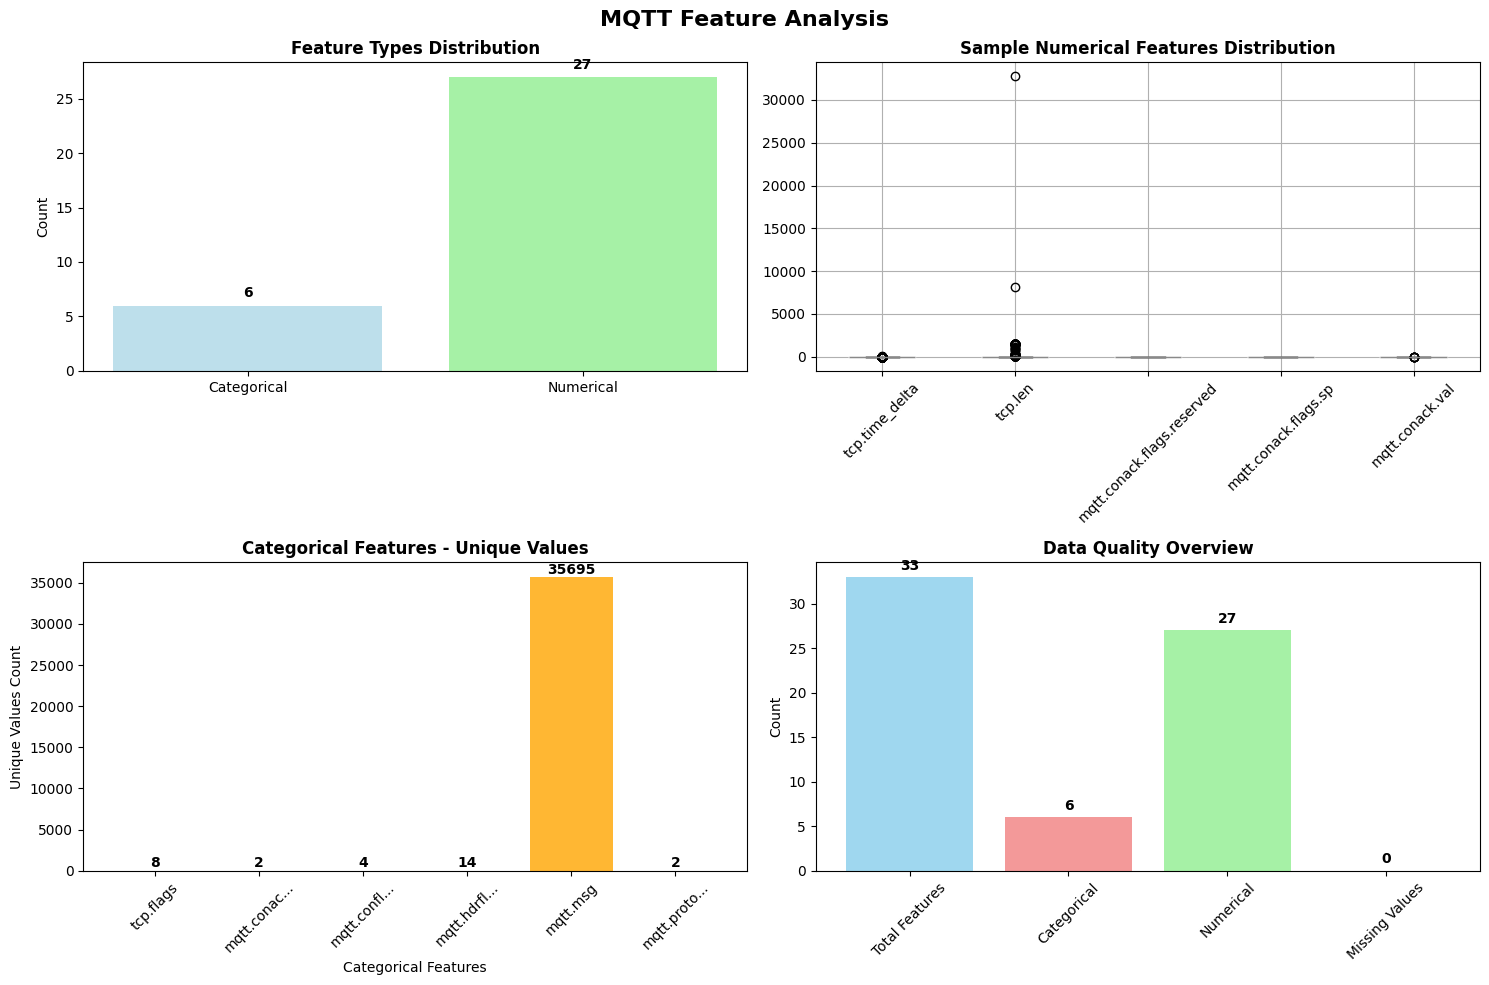

In [6]:
# Feature analysis visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('MQTT Feature Analysis', fontsize=16, fontweight='bold')

# 1. Categorical vs Numerical features
ax1 = axes[0, 0]
feature_types = ['Categorical', 'Numerical']
feature_counts = [len(categorical_cols), len(numerical_cols)]
colors = ['lightblue', 'lightgreen']
bars = ax1.bar(feature_types, feature_counts, color=colors, alpha=0.8)
ax1.set_title('Feature Types Distribution', fontweight='bold')
ax1.set_ylabel('Count')
for bar, count in zip(bars, feature_counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             str(count), ha='center', va='bottom', fontweight='bold')

# 2. Sample of numerical features distribution
ax2 = axes[0, 1]
sample_numerical = X_train[numerical_cols[:5]].sample(1000)  # Sample for speed
sample_numerical.boxplot(ax=ax2)
ax2.set_title('Sample Numerical Features Distribution', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

# 3. Categorical features info
ax3 = axes[1, 0]
cat_info = []
for col in categorical_cols:
    unique_count = X_train[col].nunique()
    cat_info.append(unique_count)

bars = ax3.bar(range(len(categorical_cols)), cat_info, color='orange', alpha=0.8)
ax3.set_title('Categorical Features - Unique Values', fontweight='bold')
ax3.set_xlabel('Categorical Features')
ax3.set_ylabel('Unique Values Count')
ax3.set_xticks(range(len(categorical_cols)))
ax3.set_xticklabels([col[:10] + '...' if len(col) > 10 else col for col in categorical_cols], rotation=45)
for bar, count in zip(bars, cat_info):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             str(count), ha='center', va='bottom', fontweight='bold')

# 4. Data quality overview
ax4 = axes[1, 1]
quality_metrics = ['Total Features', 'Categorical', 'Numerical', 'Missing Values']
quality_values = [len(X_train.columns), len(categorical_cols), len(numerical_cols), X_train.isnull().sum().sum()]
colors = ['skyblue', 'lightcoral', 'lightgreen', 'orange']
bars = ax4.bar(quality_metrics, quality_values, color=colors, alpha=0.8)
ax4.set_title('Data Quality Overview', fontweight='bold')
ax4.set_ylabel('Count')
ax4.tick_params(axis='x', rotation=45)
for bar, value in zip(bars, quality_values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             str(value), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('Images/Phase1_MQTT_feature_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## BƯỚC 4: ENCODE CATEGORICAL FEATURES (OPTIMIZED)

In [7]:
print("\nBƯỚC 4: ENCODE CATEGORICAL FEATURES")
print("-" * 40)

feature_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    
    # Handle unseen labels (optimized)
    test_values = X_test[col].astype(str).values
    class_to_idx = {cls: idx for idx, cls in enumerate(le.classes_)}
    X_test[col] = np.array([class_to_idx.get(val, 0) for val in test_values])
    
    feature_encoders[col] = le
    unseen = np.sum([val not in class_to_idx for val in test_values])
    print(f"  {col}: {len(le.classes_)} classes, {unseen} unseen")

print(f"\nTotal encoders: {len(feature_encoders)}")


BƯỚC 4: ENCODE CATEGORICAL FEATURES
----------------------------------------
  tcp.flags: 8 classes, 0 unseen
  mqtt.conack.flags: 2 classes, 0 unseen
  mqtt.conflags: 4 classes, 0 unseen
  mqtt.hdrflags: 14 classes, 0 unseen
  mqtt.msg: 35695 classes, 16647 unseen
  mqtt.protoname: 2 classes, 0 unseen

Total encoders: 6


## BƯỚC 5: ENCODE LABELS

In [8]:
print("\nBƯỚC 5: ENCODE LABELS")
print("-" * 40)

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)
for idx, label in enumerate(label_encoder.classes_):
    print(f"  {idx}: {label}")


BƯỚC 5: ENCODE LABELS
----------------------------------------
Classes: ['bruteforce' 'dos' 'flood' 'legitimate' 'malformed' 'slowite']
  0: bruteforce
  1: dos
  2: flood
  3: legitimate
  4: malformed
  5: slowite


## BƯỚC 6: CHUẨN HÓA DỮ LIỆU

In [9]:
print("\nBƯỚC 6: CHUẨN HÓA DỮ LIỆU")
print("-" * 40)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print(f"Scaled train: {X_train_scaled.shape}")
print(f"Scaled test: {X_test_scaled.shape}")


BƯỚC 6: CHUẨN HÓA DỮ LIỆU
----------------------------------------
Scaled train: (231646, 33)
Scaled test: (99290, 33)


## BƯỚC 7: LƯU DỮ LIỆU

In [10]:
print("\nBƯỚC 7: LƯU DỮ LIỆU")
print("-" * 40)

X_train_scaled.to_csv('Phase1_Data/X_train_processed.csv', index=False)
X_test_scaled.to_csv('Phase1_Data/X_test_processed.csv', index=False)
pd.DataFrame(y_train_encoded, columns=['label']).to_csv('Phase1_Data/y_train_processed.csv', index=False)
pd.DataFrame(y_test_encoded, columns=['label']).to_csv('Phase1_Data/y_test_processed.csv', index=False)

with open('Phase1_Models/mqtt_feature_encoders.pkl', 'wb') as f:
    pickle.dump(feature_encoders, f)
with open('Phase1_Models/mqtt_label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
with open('Phase1_Models/mqtt_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Đã lưu tất cả files")


BƯỚC 7: LƯU DỮ LIỆU
----------------------------------------
✅ Đã lưu tất cả files


In [11]:
print("\n" + "=" * 60)
print("HOÀN THÀNH PHASE 1!")
print("=" * 60)
print(f"Features: {X_train_scaled.shape[1]}")
print(f"Classes: {len(label_encoder.classes_)}")
print(f"Train: {len(X_train_scaled)}, Test: {len(X_test_scaled)}")


HOÀN THÀNH PHASE 1!
Features: 33
Classes: 6
Train: 231646, Test: 99290
